In [1]:
%matplotlib inline
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import distance
from scipy import stats
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

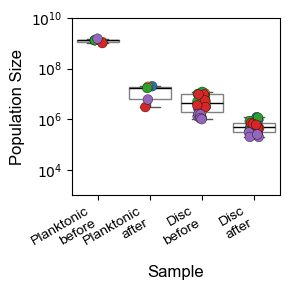

In [2]:
plt.figure(figsize = [3,3])

df_impact_refill = pd.read_excel('Impact_of_refill_on_discs.xlsx', sheet_name='Sheet1', index_col=0)
#Construcy a strip plot to show each time point individually
sns.stripplot(data=df_impact_refill, x="Sample", y="R1",  hue = 'Well', s=7, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(data=df_impact_refill, x="Sample", y="R1",boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))

plt.ylim([1000,10**10])
plt.yscale('log')
plt.xticks(rotation = 30, ha = 'right', fontname = 'arial', fontsize = 10)
plt.xticks(fontname = 'arial', fontsize = 10)

plt.xlabel('Sample', fontname = 'Arial', fontsize = 12)
plt.ylabel('Population Size', fontname = 'Arial', fontsize = 12)

plt.tight_layout()
plt.savefig('Figures paper/Impact binding.svg', format = 'svg', dpi = 300)

In [3]:
#Statistical test of significance to compare population size before and after refinn on Planktonic
stats.ttest_ind(df_impact_refill.loc[df_impact_refill.Sample == 'Planktonic\nbefore'].R1.values,\
df_impact_refill.loc[df_impact_refill.Sample == 'Planktonic\nafter'].R1.values)


TtestResult(statistic=np.float64(14.063094979203145), pvalue=np.float64(6.346765348046528e-07), df=np.float64(8.0))

In [4]:
#Statistical test of significance to compare population size before and after refinn on Disc/
stats.ttest_ind(df_impact_refill.loc[df_impact_refill.Sample == 'Disc\nbefore'].R1.values,\
df_impact_refill.loc[df_impact_refill.Sample == 'Disc\nafter'].R1.values)

TtestResult(statistic=np.float64(6.4896348146897465), pvalue=np.float64(4.4611271615283143e-08), df=np.float64(48.0))

In [5]:
#Mean population size before and after refill
df_impact_refill[['Sample','R1']].groupby('Sample').mean()

,R1
Sample,
Disc\nafter,5.380000e+05
Disc\nbefore,5.408000e+06
Planktonic\nafter,1.300000e+07
Planktonic\nbefore,1.240000e+09


In [6]:
#Mean population size before and after refill
df_impact_refill[['Sample','R1']].groupby('Sample').std()

,R1
Sample,
Disc\nafter,2.818392e+05
Disc\nbefore,3.741537e+06
Planktonic\nafter,7.905694e+06
Planktonic\nbefore,1.949359e+08


In [7]:
"""
You can start the code from here
"""
#Import the actual data
df_biofilm_filtered = pd.read_csv('Figurewise raw data/Biofilm_filtered.csv', index_col = 0)
df_biofilm_filtered.head()

,3,8,28,32,42,64,70,78,100,108,...,t_27_enrichment,t_39_enrichment,t_45_enrichment,t_63_enrichment,t_73_enrichment,t_81_enrichment,t_99_enrichment,t_107_enrichment,t_115_enrichment,t_137_enrichment
barcode,,,,,,,,,,,,,,,,,,,,,
GCGTATCGGAACTAGAAGGG,0,1,7,3,1,0,3,1,3,3,...,0.301030,0.602060,0.301030,0.602060,1.255273,1.146128,0.903090,0.000000,0.000000,0.000000
ACTGGAGAGACGCTCCAAGT,0,5,1,0,2,0,1,2,0,0,...,0.301030,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.301030,0.000000
GTTTTTAAATGTGTGCCCGG,1,4,1,3,9,0,4,0,0,0,...,-0.301030,-0.301030,0.397940,0.301030,-0.301030,-0.301030,-0.301030,-0.301030,-0.301030,-0.301030
GTACTAAATTGATGCCCATT,10,0,0,0,0,0,0,2,3,0,...,-0.740363,-1.041393,-1.041393,-0.740363,-1.041393,-1.041393,-1.041393,-1.041393,-1.041393,-1.041393
GGCCAAAGTACCTGTTAAAT,7,4,4,4,6,10,5,9,3,4,...,-0.903090,-0.425969,0.096910,-0.903090,-0.903090,-0.425969,-0.903090,-0.903090,-0.425969,-0.903090


In [ ]:
"""
We will make a plot with the distribution of frequencies at each time point
"""
list_files = ['3','9','29','33','46','65','74','82','101','109','117','138','142','146','161','165','169']
list_columns = []
for i in list_files:
    df_biofilm_filtered.loc[:,'t_'+i+'_f'] = df_biofilm_filtered[i]/df_biofilm_filtered[i].sum()
    list_columns.append('t_'+i+'_f')
df_biofilm_filtered

#df1 = df_biofilm_filtered[list_columns].sample(n=100, replace=False) #len(df_biofilm_filtered)

df1 = df_biofilm_filtered[list_columns].sort_values('t_169_f', ascending = 0)[0:10000].sample(n=10000, replace=False)

df1.transpose().plot.area(legend=False, rasterized = True, figsize = (6,3))
plt.yticks(fontname = 'Arial',fontsize = 12);
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],\
           ['0','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16'],fontname = 'Arial',fontsize = 12);
plt.xlabel('Days',fontname = 'Arial',fontsize = 14);
plt.ylabel('Frequency',fontname = 'Arial',fontsize = 14);

plt.savefig('Figures paper/Replicate 1 Muller.svg', format = 'svg', dpi = 300)

In [ ]:
"""
We will make a plot with the distribution of frequencies at each time point
"""
list_files = ['3','8','28','32','42','64','70','78','100','108','116','134','140','144','160','164','168']
list_columns = []
for i in list_files:
    df_biofilm_filtered.loc[:,'t_'+i+'_f'] = df_biofilm_filtered[i]/df_biofilm_filtered[i].sum()
    list_columns.append('t_'+i+'_f')
df_biofilm_filtered

df1 = df_biofilm_filtered[list_columns].sample(n=len(df_biofilm_filtered), replace=False)
df1.transpose().plot.area(legend=False, rasterized = True, figsize = (6,3))
plt.yticks(fontname = 'Arial',fontsize = 12);
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],\
           ['0','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16'],fontname = 'Arial',fontsize = 12);
plt.xlabel('Days',fontname = 'Arial',fontsize = 14);
plt.ylabel('Frequency',fontname = 'Arial',fontsize = 14);

plt.savefig('Figures paper/Replicate 2 Muller.svg', format = 'svg', dpi = 300)

In [8]:
#We extract neutral barcodes. The neutral barcodes were determined using sequencing and correspond to barcodes without mutations.
Neutral_barcodes = pd.read_csv('Neutral_barcodes.csv', index_col=0)
Neutral_barcodes_true = []

#Extract the true barcodes from the neutral barcode list.
for barcode in Neutral_barcodes.Barcode:
    Neutral_barcodes_true.append(barcode[2:7]+barcode[9:14]+barcode[16:21]+barcode[23:28])

#We make a dataframe with just the Neutral barcodes.
df_neutral = df_biofilm_filtered.loc[df_biofilm_filtered.index.isin(Neutral_barcodes_true)]

#We create an artificial barcode called as 'WT', which is the sum of all neutral barcode.
#This wildtype barcode serves as a reference for all neutral barcodes.
df_biofilm_filtered.loc['WT'] = df_neutral.sum()
df_biofilm_filtered

,3,8,28,32,42,64,70,78,100,108,...,t_27_enrichment,t_39_enrichment,t_45_enrichment,t_63_enrichment,t_73_enrichment,t_81_enrichment,t_99_enrichment,t_107_enrichment,t_115_enrichment,t_137_enrichment
barcode,,,,,,,,,,,,,,,,,,,,,
GCGTATCGGAACTAGAAGGG,0.0,1.0,7.0,3.0,1.0,0.0,3.0,1.0,3.0,3.0,...,0.301030,0.602060,0.301030,0.602060,1.255273,1.146128,0.903090,0.000000,0.000000,0.000000
ACTGGAGAGACGCTCCAAGT,0.0,5.0,1.0,0.0,2.0,0.0,1.0,2.0,0.0,0.0,...,0.301030,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.301030,0.000000
GTTTTTAAATGTGTGCCCGG,1.0,4.0,1.0,3.0,9.0,0.0,4.0,0.0,0.0,0.0,...,-0.301030,-0.301030,0.397940,0.301030,-0.301030,-0.301030,-0.301030,-0.301030,-0.301030,-0.301030
GTACTAAATTGATGCCCATT,10.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,0.0,...,-0.740363,-1.041393,-1.041393,-0.740363,-1.041393,-1.041393,-1.041393,-1.041393,-1.041393,-1.041393
GGCCAAAGTACCTGTTAAAT,7.0,4.0,4.0,4.0,6.0,10.0,5.0,9.0,3.0,4.0,...,-0.903090,-0.425969,0.096910,-0.903090,-0.903090,-0.425969,-0.903090,-0.903090,-0.425969,-0.903090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTTGACGGAGGGCTG-ATTC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CGCACAAGAGAACGCGAAAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.477121
CAGTAATTTCGTTATATAAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [9]:
#Here I write the code for calculating the fitness for each variant
"""
OLS SM model : least squares model is better
"""
# import and fit an OLS model, check coefficients
import statsmodels.api as sm

def calc_slope_sklearn(row):
    """
    I use the sklearn regression package for weighted linear regression.
    We perform the linear regression over 3 consequitive time points.
    In the method, we return the slope.
    """
    y= row[[0,1,2]]
    #x = [0,1,2]
    x = [0,1,2]
    x = sm.add_constant(x)
    w = row[['0_w','1_w','2_w']]
    model = sm.WLS(y,x,weights=w)
    results = model.fit()
    return results.params.iloc[1]

def calc_slope_sklearn2(row):
    """
    I use the sklearn regression package for weighted linear regression.
    We perform the linear regression over 3 consequitive time points.
    In the method, we return the slope.

    For one of the timepoints, we have a timepoint missing. For the same
    we do regression over the missing timepoint taking the three consecutive
    timepoints one with a day difference and another with a 2 day difference.
    """
    y= row[[0,1,2]]
    x = [0,1,3]
    x = sm.add_constant(x)
    w = row[['0_w','1_w','2_w']]
    model = sm.WLS(y,x,weights=w)
    results = model.fit()
    return results.params.iloc[1]

# import and fit an OLS model, check coefficients
import statsmodels.api as sm
def calc_slope_sklearn3(row):
    """
    I use the sklearn regression package for weighted linear regression.
    We perform the linear regression over 3 consequitive time points.
    In the method, we return the slope.

    For one of the timepoints, we have a timepoint missing. For the same
    we do regression over the missing timepoint taking the three consecutive
    timepoints one with a two day difference and another with a day difference.
    """
    y= row[[0,1,2]]
    x = [0,2,3]
    x = sm.add_constant(x)
    w = row[['0_w','1_w','2_w']]
    model = sm.WLS(y,x,weights=w)
    results = model.fit()
    return results.params.iloc[1]



def calc_r2_sklearn(row):
    """
    I use the sklearn regression package for weighted linear regression.
    We perform the linear regression over 3 consequitive time points.
    In the method, we return the R2.
    """
    y= row[[0,1,2]]
    x = [0,1,2]
    #x = [0,8.23,16.46]
    x = sm.add_constant(x)
    w = row[['0_w','1_w','2_w']]
    model = sm.WLS(y,x,weights=w)
    results = model.fit()
    return results.rsquared

def calc_error_sklearn(row):
    """
    I use the sklearn regression package for weighted linear regression.
    We perform the linear regression over 3 consequitive time points.
    In the method, we return the error in the estimation of slope.
    """
    y= row[[0,1,2]]
    x = [0,1,2]
    #x = [0,8.23,16.46]
    x = sm.add_constant(x)
    w = row[['0_w','1_w','2_w']]
    model = sm.WLS(y,x,weights=w)
    results = model.fit()
    return results.bse.iloc[1]

def calc_error_sklearn2(row):
    """
    I use the sklearn regression package for weighted linear regression.
    We perform the linear regression over 3 consequitive time points.
    In the method, we return the slope.
    """
    y= row[[0,1,2]]
    x = [0,1,3]
    x = sm.add_constant(x)
    w = row[['0_w','1_w','2_w']]
    model = sm.WLS(y,x,weights=w)
    results = model.fit()
    return results.bse.iloc[1]

def calc_error_sklearn3(row):
    """
    I use the sklearn regression package for weighted linear regression.
    We perform the linear regression over 3 consequitive time points.
    In the method, we return the slope.
    """
    y= row[[0,1,2]]
    x = [0,2,3]
    x = sm.add_constant(x)
    w = row[['0_w','1_w','2_w']]
    model = sm.WLS(y,x,weights=w)
    results = model.fit()
    return results.bse.iloc[1]

In [10]:
import warnings

# Suppress ONLY runtime warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

list_columns = ['3','9','29','46','65','74','82','101','109','117','138','142','146','161','165','169']
#df_biofilm_filtered = df_biofilm_filtered[list_columns]

#Initiate two lists to save the names of the ratio columns and weight columns.
ratio_columns = []
weight_coumns = []

#Here we estimate the log ratio in frequencies and the associated weights for linear regression
for colum in list_columns:
    #Estimating the log ratio
    df_biofilm_filtered.loc[:,colum+'ratio'] = ((df_biofilm_filtered[colum]+0.5)/(df_biofilm_filtered.loc['WT', colum]+0.5)).apply(np.log)
    ratio_columns.append(colum+'ratio')

    #Estimating the weigt
    df_biofilm_filtered.loc[:,colum+'weight'] = 1/(1/(df_biofilm_filtered[colum]+0.5)+1/(df_biofilm_filtered.loc['WT',colum]+0.5))
    weight_coumns.append(colum+'weight')

#We will estimate the slope of each trajectory in a rolling window of every 3 consecutive time points.
#Initiate a list to save the name of the slope columns
slope_columns = []
for i in range(0,14):
    print(i)
    print(list_columns[i:i+3])
    #The slopes for variants with low counts can be erroneous and associated with errors
    #We only calculate slopes for variants which have atleast 25 reads for all 3 consecutive time points
    #25/250000 = 0.0001 ~usually the number of reads associated with erroneous reads.
    df_slope = df_biofilm_filtered.loc[(df_biofilm_filtered[list_columns[i:i+3]] >= 50).any(axis = 1)][ratio_columns[i:i+3] + (weight_coumns[i:i+3])]
    df_slope.columns = [0,1,2,'0_w','1_w','2_w']

    #We now update the slope for each window
    df_biofilm_filtered['slope_'+str(i)] = df_slope.apply(calc_slope_sklearn,axis=1)
    slope_columns.append('slope_'+str(i))

    #We store the r2 for each variant for each window
    df_biofilm_filtered['r2_'+str(i)] = df_slope.apply(calc_r2_sklearn,axis=1)

    #We store the error for each variant for each window
    df_biofilm_filtered['error_'+str(i)] = df_slope.apply(calc_error_sklearn,axis=1)

df_biofilm_filtered

0
['3', '9', '29']
1
['9', '29', '46']
2
['29', '46', '65']
3
['46', '65', '74']
4
['65', '74', '82']
5
['74', '82', '101']
6
['82', '101', '109']
7
['101', '109', '117']
8
['109', '117', '138']
9
['117', '138', '142']
10
['138', '142', '146']
11
['142', '146', '161']
12
['146', '161', '165']
13
['161', '165', '169']


,3,8,28,32,42,64,70,78,100,108,...,error_10,slope_11,r2_11,error_11,slope_12,r2_12,error_12,slope_13,r2_13,error_13
barcode,,,,,,,,,,,,,,,,,,,,,
GCGTATCGGAACTAGAAGGG,0.0,1.0,7.0,3.0,1.0,0.0,3.0,1.0,3.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACTGGAGAGACGCTCCAAGT,0.0,5.0,1.0,0.0,2.0,0.0,1.0,2.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GTTTTTAAATGTGTGCCCGG,1.0,4.0,1.0,3.0,9.0,0.0,4.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GTACTAAATTGATGCCCATT,10.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GGCCAAAGTACCTGTTAAAT,7.0,4.0,4.0,4.0,6.0,10.0,5.0,9.0,3.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTTGACGGAGGGCTG-ATTC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CGCACAAGAGAACGCGAAAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAGTAATTTCGTTATATAAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
"""
For two windows, we did not have consecutive points. 
Therefore, for these windows, we re-do fitness estimates with a gap in between
"""

df_slope = df_biofilm_filtered.loc[(df_biofilm_filtered[['9','29','46']] >= 50).any(axis = 1)]\
[['9ratio','29ratio','46ratio','9weight','29weight','46weight']]
df_slope.columns = [0,1,2,'0_w','1_w','2_w']
#We now update the slope for each window
df_biofilm_filtered['slope_1'] = df_slope.apply(calc_slope_sklearn2,axis=1)
df_biofilm_filtered['error_1'] = df_slope.apply(calc_error_sklearn2,axis=1)

df_slope = df_biofilm_filtered.loc[(df_biofilm_filtered[['29','46','65']] >= 50).any(axis = 1)]\
[['29ratio','46ratio','65ratio','29weight','46weight','65weight']]
df_slope.columns = [0,1,2,'0_w','1_w','2_w']
#We now update the slope for each window
df_biofilm_filtered['slope_2'] = df_slope.apply(calc_slope_sklearn3,axis=1)
df_biofilm_filtered['error_2'] = df_slope.apply(calc_error_sklearn3,axis=1)

0.8375972815594639


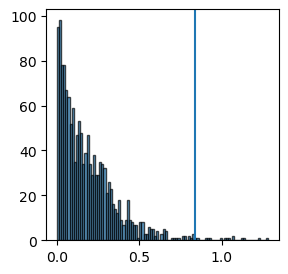

In [12]:
#Estimate the error cutoff over which, we eliminate all the slopes.
error_array = []
for i in range(13):
    error_array.append('error_'+str(i))
    
#We get a table with error for all calculated slopes for all variants.
df = pd.DataFrame(df_biofilm_filtered[error_array].stack())

#We make a histogram of error values. We set the cutoff for the error as 75th percentile.
plt.figure(figsize = [3,3])
plt.hist(df.loc[(df[0]>0)], bins=100, alpha=0.7, edgecolor="black")
cutoff = np.quantile(df.loc[(df[0]>0)], 0.99)
print(cutoff)

plt.axvline(x = cutoff)

In [13]:
#Now we filter values over the cutoff value.

df_biofilm_filtered = df_biofilm_filtered.replace(np.nan,0)

for i in range(0,13):
    df_biofilm_filtered.loc[df_biofilm_filtered['error_'+str(i)] >= cutoff, 'slope_'+str(i)] = 0
    df_biofilm_filtered.loc[df_biofilm_filtered['error_'+str(i)] >= cutoff, 'error_'+str(i)] = 0

In [14]:
#We take the fitness with the maximum slope, assuming maximum fitness fitness
df_biofilm_filtered['Fitness'] = df_biofilm_filtered[slope_columns[2:]].max(axis = 1)
df_beneficial = df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0]
df_beneficial

,3,8,28,32,42,64,70,78,100,108,...,slope_11,r2_11,error_11,slope_12,r2_12,error_12,slope_13,r2_13,error_13,Fitness
barcode,,,,,,,,,,,,,,,,,,,,,
TCTAAAATAGGCACCTACTT,5.0,4.0,7.0,4.0,2.0,0.0,4.0,5.0,2.0,3.0,...,0.147058,0.251873,0.253446,-0.236325,0.992914,0.019964,-0.225202,0.994299,0.017053,0.518157
TTGTGACCCTGTTGTCTGCA,10.0,15.0,33.0,9.0,20.0,26.0,21.0,19.0,37.0,41.0,...,-0.013156,0.002841,0.246467,-0.171927,0.506794,0.169606,0.470385,0.876104,0.176891,0.470385
CCATCCGTCTTTTTAGTATA,298.0,307.0,270.0,324.0,304.0,279.0,324.0,342.0,312.0,287.0,...,0.043025,0.036087,0.222364,-0.052555,0.069009,0.193035,0.352199,0.981339,0.048567,0.352199
TGCCGGATGCATTAATACAA,4.0,10.0,17.0,18.0,5.0,8.0,7.0,1.0,8.0,14.0,...,0.002652,0.003313,0.046006,0.081112,0.386906,0.102105,0.475531,0.933571,0.126848,0.475531
CCGGAAGAACTCTTTTACCC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.363794,0.338582,0.508466,0.203267,0.343847,0.280793,0.320199,0.631290,0.244708,1.404027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTTGCAACACACTTGACCCA,3.0,14.0,9.0,14.0,15.0,10.0,28.0,12.0,23.0,15.0,...,-0.040288,0.080652,0.136022,0.202680,0.346873,0.278114,0.229566,0.344918,0.316372,0.375350
GGGAGTCTCCCTGTTTTCGC,10.0,3.0,3.0,4.0,4.0,8.0,11.0,5.0,7.0,10.0,...,-0.656275,0.927907,0.182928,0.076952,0.021147,0.523548,0.468908,0.474292,0.493670,0.596146
GGACCTGAGGCATTGTAGAC,2.0,10.0,7.0,2.0,2.0,10.0,4.0,9.0,9.0,5.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.329975


In [15]:
"""
Importing the fitness values as determined by popDMS
"""

#We assign each barcode as neutral or non neutral
df_biofilm_filtered['is_WT'] = 'False'
df_biofilm_filtered.loc[df_biofilm_filtered.index.isin(df_neutral.index),'is_WT'] = 'True'
df_biofilm_filtered.loc['WT','is_WT'] = 'True'

#We import the fitness
df_Fitness_estimates = pd.read_csv('popDMS/Biofilms_rep3_Fitnesses.csv', index_col=0)
df_biofilm_filtered = pd.concat([df_biofilm_filtered,df_Fitness_estimates], axis = 1)
df_biofilm_filtered

,3,8,28,32,42,64,70,78,100,108,...,fitness_normed_D,fitness_normed_E,fitness_normed_F,fitness_normed_G,fitness_normed_H,fitness_normed_I,fitness_normed_J,fitness_normed_K,fitness_normed_L,fitness_normed_M
barcode,,,,,,,,,,,,,,,,,,,,,
GCGTATCGGAACTAGAAGGG,0.0,1.0,7.0,3.0,1.0,0.0,3.0,1.0,3.0,3.0,...,0.515000,-0.164601,0.399931,-0.017886,-1.168375,-0.637951,0.832525,0.729984,-0.111329,-0.912684
ACTGGAGAGACGCTCCAAGT,0.0,5.0,1.0,0.0,2.0,0.0,1.0,2.0,0.0,0.0,...,-0.089300,1.148533,-0.161937,-1.572372,-0.098811,-0.051738,-0.092917,0.026365,-0.133367,-0.186062
GTTTTTAAATGTGTGCCCGG,1.0,4.0,1.0,3.0,9.0,0.0,4.0,0.0,0.0,0.0,...,-0.976164,0.478113,0.959572,-0.288029,-0.563330,-0.002704,-0.398000,0.744563,-0.016645,-0.302715
GTACTAAATTGATGCCCATT,10.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,0.0,...,-0.356318,0.435948,-0.248440,-1.212351,-0.098811,0.546752,-0.031034,-0.506800,-0.133367,-0.186062
GGCCAAAGTACCTGTTAAAT,7.0,4.0,4.0,4.0,6.0,10.0,5.0,9.0,3.0,4.0,...,-0.039364,-0.407006,-0.644837,0.023527,0.112701,-0.325415,-0.291384,0.316853,0.428971,-0.276240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTTGACGGAGGGCTG-ATTC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.107796,-0.087900,-0.046064,-0.121589,-0.098811,-0.051738,-0.092917,0.026365,-0.133367,-0.186062
CGCACAAGAGAACGCGAAAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.107796,-0.087900,-0.046064,-0.121589,-0.098811,-0.051738,-0.092917,0.026365,-0.133367,-0.186062
CAGTAATTTCGTTATATAAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.107796,-0.087900,-0.046064,-0.121589,-0.098811,-0.051738,-0.092917,0.026365,-0.133367,-0.186062


In [16]:
#Just as the linear regrssion, the popDMS fitness was determined over windows
window_names = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N']
W0 = ['3', '9', '29']
W1 = ['9', '29', '46']
W2 = ['29','46','65']
W3 = ['46', '65', '74']
W4 = ['65', '74', '82']
W5 = ['74', '82', '101']
W6 = ['82', '101', '109']
W7 = ['101', '109', '117']
W8 = ['109', '117', '138']
W9 = ['117', '138', '142']
W10 = ['138', '142', '146']
W11 = ['142', '146', '161']
W12 = ['146', '161', '165']
W13 = ['161', '165', '169']

list_windows = [W0,W1,W2,W3,W4,W5,W6,W7,W8,W9,W10,W11,W12,W13]

fitness_columns = []

#We pull the estimated fitness from each of the windows, done using POP DMS
i = 0
for window in list_windows:
    print(window)
    #Here again we consider all variants with reads less than 25
    df_biofilm_filtered.loc[(df_biofilm_filtered[window] >= 50).any(axis = 1) == False, 'fitness_normed_'+window_names[i]] = 0
    df_biofilm_filtered['slope_'+window_names[i]] = df_biofilm_filtered['fitness_normed_'+window_names[i]]
    fitness_columns.append('slope_'+window_names[i])
    i = i+1
df_biofilm_filtered  

['3', '9', '29']
['9', '29', '46']
['29', '46', '65']
['46', '65', '74']
['65', '74', '82']
['74', '82', '101']
['82', '101', '109']
['101', '109', '117']
['109', '117', '138']
['117', '138', '142']
['138', '142', '146']
['142', '146', '161']
['146', '161', '165']
['161', '165', '169']


,3,8,28,32,42,64,70,78,100,108,...,slope_F,slope_G,slope_H,slope_I,slope_J,slope_K,slope_L,slope_M,fitness_normed_N,slope_N
barcode,,,,,,,,,,,,,,,,,,,,,
GCGTATCGGAACTAGAAGGG,0.0,1.0,7.0,3.0,1.0,0.0,3.0,1.0,3.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTGGAGAGACGCTCCAAGT,0.0,5.0,1.0,0.0,2.0,0.0,1.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GTTTTTAAATGTGTGCCCGG,1.0,4.0,1.0,3.0,9.0,0.0,4.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GTACTAAATTGATGCCCATT,10.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GGCCAAAGTACCTGTTAAAT,7.0,4.0,4.0,4.0,6.0,10.0,5.0,9.0,3.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTTGACGGAGGGCTG-ATTC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CGCACAAGAGAACGCGAAAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CAGTAATTTCGTTATATAAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
#We take the fitness with the maximum slope, assuming maximum fitness gain
df_biofilm_filtered['Fitness_pDMS'] = df_biofilm_filtered[fitness_columns].max(axis = 1)
df_beneficial2 = df_biofilm_filtered.loc[df_biofilm_filtered.Fitness_pDMS > 0]
df_beneficial2

,3,8,28,32,42,64,70,78,100,108,...,slope_G,slope_H,slope_I,slope_J,slope_K,slope_L,slope_M,fitness_normed_N,slope_N,Fitness_pDMS
barcode,,,,,,,,,,,,,,,,,,,,,
TCTAAAATAGGCACCTACTT,5.0,4.0,7.0,4.0,2.0,0.0,4.0,5.0,2.0,3.0,...,0.516670,0.399285,0.175322,-0.316142,-0.020333,0.173081,-0.220732,NaN,NaN,0.516670
TTGTGACCCTGTTGTCTGCA,10.0,15.0,33.0,9.0,20.0,26.0,21.0,19.0,37.0,41.0,...,0.122840,0.371796,-0.089004,-0.156020,0.331902,-0.014246,-0.177665,NaN,NaN,0.371796
CCATCCGTCTTTTTAGTATA,298.0,307.0,270.0,324.0,304.0,279.0,324.0,342.0,312.0,287.0,...,-0.109040,0.015900,0.001167,0.018296,0.241374,0.051275,-0.059446,NaN,NaN,0.241374
TGCCGGATGCATTAATACAA,4.0,10.0,17.0,18.0,5.0,8.0,7.0,1.0,8.0,14.0,...,0.006786,-0.287687,-0.123992,0.418981,0.295715,0.003008,0.074001,NaN,NaN,0.418981
CCGGAAGAACTCTTTTACCC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,1.407910,0.419174,0.206407,NaN,NaN,1.407910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTTGCAACACACTTGACCCA,3.0,14.0,9.0,14.0,15.0,10.0,28.0,12.0,23.0,15.0,...,0.072678,0.428621,0.200234,0.066030,0.262053,-0.046735,0.207256,NaN,NaN,0.428621
GGGAGTCTCCCTGTTTTCGC,10.0,3.0,3.0,4.0,4.0,8.0,11.0,5.0,7.0,10.0,...,0.071970,-0.016494,0.106241,0.687356,0.193660,-0.740061,0.071786,NaN,NaN,0.687356
GGACCTGAGGCATTGTAGAC,2.0,10.0,7.0,2.0,2.0,10.0,4.0,9.0,9.0,5.0,...,0.000000,0.000000,0.258063,0.351448,-0.188954,0.000000,0.000000,0.0,0.0,0.351448


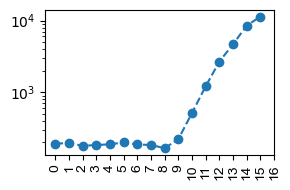

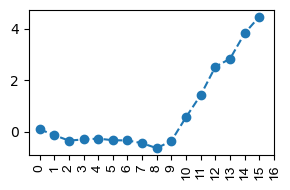

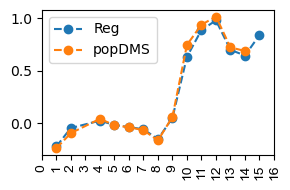

In [18]:
plt.figure(figsize = [3,2])
plt.plot(df_beneficial.loc['GTCGCGCTCGTAGCATACAA'][list_columns],'o--')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],\
           ['0','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16'],\
           fontname = 'Arial', rotation = 90, fontsize = 10);
plt.yscale('log')
plt.tight_layout()
plt.savefig('Figures paper/Trajectory1.svg', format = 'svg', dpi = 300)

plt.figure(figsize = [3,2])
plt.plot(df_beneficial.loc['GTCGCGCTCGTAGCATACAA'][ratio_columns],'o--')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],\
           ['0','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16'],fontname = 'Arial', rotation = 90, fontsize = 10);
plt.tight_layout()
plt.savefig('Figures paper/Trajectory1_trans.svg', format = 'svg', dpi = 300)

plt.figure(figsize = [3,2])
plt.plot([1,2,4,5,6,7,8,9,10,11,12,13,14,15],df_biofilm_filtered.loc['GTCGCGCTCGTAGCATACAA'][slope_columns],'o--', label = 'Reg')
plt.plot([1,2,4,5,6,7,8,9,10,11,12,13,14,15],df_biofilm_filtered.loc['GTCGCGCTCGTAGCATACAA'][fitness_columns],'o--', label = 'popDMS')

plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],\
           ['0','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16'],fontname = 'Arial', rotation = 90, fontsize = 10);
plt.legend()
plt.tight_layout()
plt.savefig('Figures paper/Trajectory1_Slopes.svg', format = 'svg', dpi = 300)

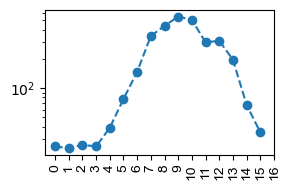

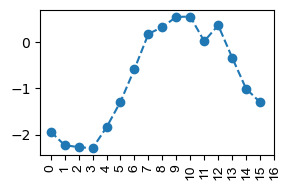

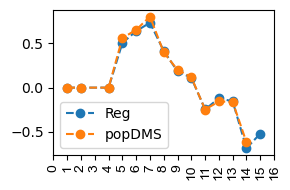

In [19]:
plt.figure(figsize = [3,2])
plt.plot(df_beneficial.loc['CACTGGAGCTATCCCTTTAG'][list_columns],'o--')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],\
           ['0','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16'],\
           fontname = 'Arial', rotation = 90, fontsize = 10);
plt.yscale('log')
plt.tight_layout()
plt.savefig('Figures paper/Trajectory2.svg', format = 'svg', dpi = 300)

plt.figure(figsize = [3,2])
plt.plot(df_beneficial.loc['CACTGGAGCTATCCCTTTAG'][ratio_columns],'o--')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],\
           ['0','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16'],fontname = 'Arial', rotation = 90, fontsize = 10);
plt.tight_layout()
plt.savefig('Figures paper/Trajectory2_trans.svg', format = 'svg', dpi = 300)

plt.figure(figsize = [3,2])
plt.plot([1,2,4,5,6,7,8,9,10,11,12,13,14,15],df_biofilm_filtered.loc['CACTGGAGCTATCCCTTTAG'][slope_columns],'o--', label = 'Reg')
plt.plot([1,2,4,5,6,7,8,9,10,11,12,13,14,15],df_biofilm_filtered.loc['CACTGGAGCTATCCCTTTAG'][fitness_columns],'o--', label = 'popDMS')

plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],\
           ['0','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16'],fontname = 'Arial', rotation = 90, fontsize = 10);
plt.legend()
plt.tight_layout()
plt.savefig('Figures paper/Trajectory2_Slopes.svg', format = 'svg', dpi = 300)


SignificanceResult(statistic=np.float64(0.883147770782816), pvalue=np.float64(6.828547763203826e-78))

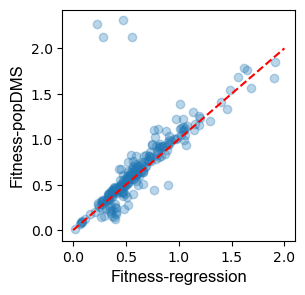

In [20]:
plt.figure(figsize = [3,3])

df_plot = df_beneficial2.loc[df_beneficial2.Fitness > 0]

plt.scatter(df_plot.Fitness, df_plot.Fitness_pDMS, alpha = 0.3, rasterized = True)
plt.plot([0,2], [0,2], linestyle = '--', color = 'red')
plt.xlabel('Fitness-regression', fontname = 'arial', fontsize = 12)
plt.ylabel('Fitness-popDMS', fontname = 'arial', fontsize = 12)
plt.savefig('Figures paper/Reg popDMS Corr.svg', format = 'svg', dpi = 300)

plt.savefig('Figures paper/CORRELATION WF verus Regression.svg', format = 'svg', dpi = 300)
stats.spearmanr(df_plot.Fitness, df_plot.Fitness_pDMS)

In [21]:
df_beneficial.to_csv('Figurewise raw data/4C. Fitness estimates replicate A.csv')

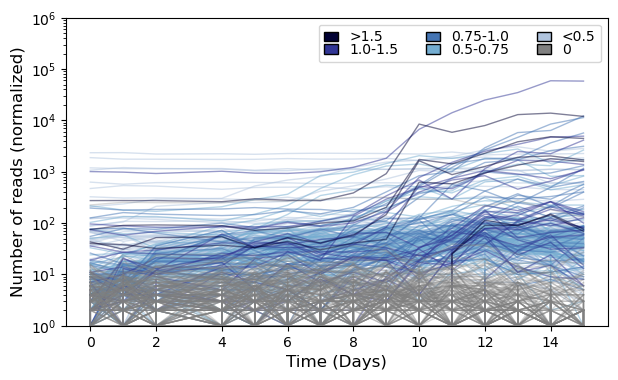

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Original columns (string sample names)
list_columns = ['3','9','29','33','46','65','74','82','101','109','117','138','142','146','161','165','169']

# Remove problematic column '33'
clean_columns = ['9','29','46','65','74','82','101','109','117','138','142','146','161','165','169']

# Define actual timepoints for remaining samples
timepoints = np.array([0,1,2,4,5,6,7,8,9,10,11,12,13,14,15])


fig, ax = plt.subplots(figsize=(7,4))

from scipy.ndimage import gaussian_filter1d

# Extract data for clean columns
df_plot = df_beneficial.loc[df_beneficial.Fitness.round(2) <= 0.5]
df_clean = df_plot[(df_plot[list_columns] >= 0).any(axis = 1)][clean_columns]
# Plot each lineage trajectory explicitly with correct x values
for _, row in df_clean.iterrows():
    ax.plot(timepoints, row.values, alpha=0.5, linewidth=1, color='lightsteelblue')


# Extract data for clean columns
df_plot = df_beneficial.loc[df_beneficial.Fitness.round(2).between(0.5,0.75)]
df_clean = df_plot[(df_plot[list_columns] >= 0).any(axis = 1)][clean_columns]
# Plot each lineage trajectory explicitly with correct x values
for _, row in df_clean.iterrows():
    ax.plot(timepoints, row.values, alpha=0.5, linewidth=1, color='#74add1')

# Extract data for clean columns
df_plot = df_beneficial.loc[df_beneficial.Fitness.round(2).between(0.75,1)]
df_clean = df_plot[(df_plot[list_columns] >= 0).any(axis = 1)][clean_columns]
# Plot each lineage trajectory explicitly with correct x values
for _, row in df_clean.iterrows():
    ax.plot(timepoints, row.values, alpha=0.5, linewidth=1, color='#4575b4')

# Extract data for clean columns
df_plot = df_beneficial.loc[df_beneficial.Fitness.round(2).between(1,1.5)]
df_clean = df_plot[(df_plot[list_columns] >= 0).any(axis = 1)][clean_columns]
# Plot each lineage trajectory explicitly with correct x values
for _, row in df_clean.iterrows():
    ax.plot(timepoints, row.values, alpha=0.5, linewidth=1, color='#313695')

# Extract data for clean columns
df_plot = df_beneficial.loc[df_beneficial.Fitness.round(2) >= 1.5]
df_clean = df_plot[(df_plot[list_columns] >= 0).any(axis = 1)][clean_columns]
# Plot each lineage trajectory explicitly with correct x values
for _, row in df_clean.iterrows():
    ax.plot(timepoints, row.values, alpha=0.5, linewidth=1, color='#000033')

# Extract data for clean columns
df_plot = df_biofilm_filtered.loc[df_biofilm_filtered.Fitness.round(2) == 0.0]
df_plot = df_plot[(df_plot[list_columns] >= 50).any(axis = 1)][list_columns]
df_clean = df_plot[clean_columns]
# Plot each lineage trajectory explicitly with correct x values
for _, row in df_clean.iterrows():
    ax.plot(timepoints, row.values, alpha=0.3, linewidth=1, color='grey')

# Format axes
ax.set_yscale('log')
ax.set_xlabel('Time (Days)', fontsize=12)
ax.set_ylabel('Reads per million', fontsize=12)
#df_biofilm_filtered.loc[df_biofilm_filtered.Fitness.round(2).between(0.05,0.075)].sort_values('Fitness')

# Format axes
ax.set_yscale('log')
ax.set_xlabel('Time (Days)', fontsize=12)
ax.set_ylabel('Number of reads (normalized)', fontsize=12)
#df_biofilm_filtered.loc[df_biofilm_filtered.Fitness.round(2).between(0.05,0.075)].sort_values('Fitness')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#000033', edgecolor='black',label='>=1.5'),\
                  Patch(facecolor='#313695', edgecolor='black',label='1-1.5'),\
                  Patch(facecolor='#4575b4', edgecolor='black',label='0.75-1'),\
                  Patch(facecolor='#74add1', edgecolor='black',label='0.5-0.75'),\
                   Patch(facecolor='lightsteelblue', edgecolor='black',label='<0.5'),\
                  Patch(facecolor='grey', edgecolor='black',label='Neutral')]

ax.legend(legend_elements, ['>1.5','1.0-1.5','0.75-1.0','0.5-0.75','<0.5','0'], labelspacing=-0.1, handlelength=1, ncol =3 , loc='upper right')
plt.ylim([1,10**6])
plt.savefig('Figures paper/Lineage trajectories by Fitness.svg', format = 'svg', dpi = 300)
plt.savefig('Figures paper/Lineage trajectories by Fitness.png', format = 'png', dpi = 300)


0.9377062194792015
                            WLS Regression Results                            
Dep. Variable:                     mu   R-squared:                       0.938
Model:                            WLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     346.2
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           2.32e-15
Time:                        15:57:15   Log-Likelihood:                -20.561
No. Observations:                  25   AIC:                             45.12
Df Residuals:                      23   BIC:                             47.56
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2605      0.291 

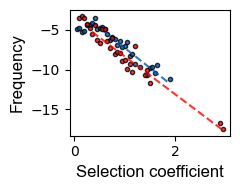

In [23]:
plt.figure(figsize = [2.5,2])
df_DFE = pd.DataFrame(((df_beneficial["Fitness"] / 0.05).round() * 0.05).value_counts()).reset_index()\
.sort_values('Fitness').rename(columns = {'count':'Count'})

mu = {}
for s in df_DFE.Fitness:
    mu[round(s,3)] = df_biofilm_filtered.loc[((df_biofilm_filtered["Fitness"] / 0.05).round() * 0.05) == s].t_117_f.sum()*s/(np.exp(s*10))
df_DFE = pd.DataFrame(mu, index=[0]).transpose()
df_DFE = df_DFE.rename(columns={0:'mu'})

plt.plot(df_DFE.index, df_DFE.mu.apply(np.log10), 'o', markersize = 3,\
         markeredgecolor = 'black', color = '#005AB5', alpha = 0.8, label = 'Rep A')

df_DFE = df_DFE.loc[df_DFE.mu > 0]

df_plot = df_DFE.loc[df_DFE.index > 0.3]
y= df_plot.mu.apply(np.log10)
x = df_plot.index
X = sm.add_constant(x)

model = sm.WLS(y,X)
results = model.fit()

print(results.rsquared)
print(results.summary())

y_pred = results.predict(X)

plt.plot(x, y_pred, '--', markersize = 5,\
         markeredgecolor = 'black', color = '#005AB5', alpha = 0.8,)
print(df_DFE.mu.sum())

df_DFE.to_csv('Figurewise raw data/4CInset.DFE RepA.csv')

df_DFE = pd.read_csv('DFE2.csv', index_col = 0)

plt.plot(df_DFE.index, df_DFE.mu.apply(np.log10), 'o', markersize = 3,\
         markeredgecolor = 'black', color = 'red', alpha = 0.8, label = 'Rep A')

df_DFE = df_DFE.loc[df_DFE.mu > 0]

df_plot = df_DFE.loc[df_DFE.index > 0.3]
y= df_plot.mu.apply(np.log10)
x = df_plot.index
X = sm.add_constant(x)

model = sm.WLS(y,X)
results = model.fit()

print(results.rsquared)
print(results.summary())

y_pred = results.predict(X)

plt.plot(x, y_pred, '--', markersize = 5,\
         markeredgecolor = 'black', color = 'red', alpha = 0.8,)
print(df_DFE.mu.sum())


plt.xlabel('Selection coefficient', fontname = 'arial', fontsize=12)
plt.ylabel('Frequency', fontname = 'arial',fontsize=12)

plt.tight_layout()
plt.savefig('Figures paper/DFE.svg', format = 'svg', dpi = 300)

df_DFE.to_csv('Figurewise raw data/4CInset.DFE RepB.csv')

In [24]:
#Fraction of population
print("Fraction of population fit in planktonic: " + str(df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0].t_169_f.sum()))
print("Fraction of population fit in disc: " + str(df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0].t_175_f.sum()))
print("Fraction of population fit in disc: " + str(df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0].t_176_f.sum()))
print("Fraction of population fit in disc: " + str(df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0].t_177_f.sum()))

Fraction of population fit in planktonic: 0.6245160000000001
Fraction of population fit in disc: 0.44260800000000006
Fraction of population fit in disc: 0.27627999999999997
Fraction of population fit in disc: 0.27123200000000003


In [25]:
np.mean([0.44260800000000006,0.27627999999999997, 0.27123200000000003])

np.float64(0.33004)

['3', '9', '29', '33', '46', '65', '74', '82', '101', '109', '117', '138', '142', '146', '161', '165', '169']
KstestResult(statistic=np.float64(0.807308120260816), pvalue=np.float64(4.314786307856332e-165), statistic_location=np.float64(0.0), statistic_sign=np.int8(1))


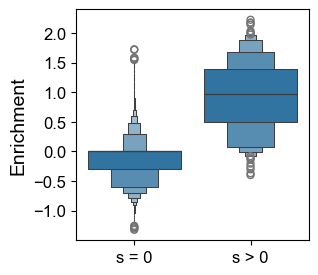

In [26]:
print(list_columns)
df_biofilm_filtered.loc[:, 'Is_fit'] = 'No'
df_biofilm_filtered.loc[df_biofilm_filtered.Fitness_pDMS > 0, 'Is_fit'] = 'Yes'
plt.figure(figsize = [3,3])

sns.boxenplot(data = df_biofilm_filtered.loc[df_biofilm_filtered.index != 'WT'], x = 'Is_fit', y = 't_169_enrichment')
#sns.stripplot(data = df_biofilm_filtered, x = 'Is_fit', y = 't_169_enrichment')

plt.yticks(fontname = 'Arial',fontsize = 12)
plt.xticks([0,1], ['s = 0', 's > 0'], fontname = 'Arial',fontsize = 12);
plt.ylabel('Enrichment', fontname = 'Arial',fontsize = 14)
plt.xlabel('', fontname = 'Arial',fontsize = 14)

plt.savefig('Figures paper/Fitness and enrichment Final.svg', format = 'svg', dpi = 300)

print(stats.ks_2samp(df_biofilm_filtered.loc[df_biofilm_filtered.Is_fit == 'No'].t_169_enrichment.dropna(),\
            df_biofilm_filtered.loc[df_biofilm_filtered.Is_fit == 'Yes'].t_169_enrichment.dropna()))

In [27]:
#Saving data
df_biofilm_filtered.loc[(df_biofilm_filtered.Fitness > 0) | (df_biofilm_filtered.Fitness_pDMS > 0)]\
[['3','9','29','46','65','74','82','101','109','117','138','142','146','161','165','169','Fitness','Fitness_pDMS']]\
.to_excel('Figurewise raw data/4E. Replicate A Beneficial Mutations.xlsx')

In [28]:
#Saving data
df_biofilm_filtered.to_csv('Figurewise raw data/Raw data with fitness Rep A.xlsx')

In [32]:
#We import the table with all the barcodes whose genoemes were sequenced at the end of the experiment
df_flask = pd.read_excel('Biofilm_curated.xlsx', index_col=0)
df_flask= \
df_flask.assign(True_Barcode = \
                          df_flask.Identified_Barcode.str[2:7]+df_flask.Identified_Barcode.str[9:14]+\
                          df_flask.Identified_Barcode.str[16:21]+df_flask.Identified_Barcode.str[23:28])

#Some of identified barcodes do not match the clustered barcode, so we correct them
df_flask.loc[df_flask.Identified_Barcode == 'TTGTCGCATGCTCGATTAGCAATTTCAAAT','True_Barcode'] = 'GTCGCGCTCGTAGCATACAA'
df_flask.loc[df_flask.Identified_Barcode == '__GATACATTCTTAATTTTAAATCGTTCAT','True_Barcode'] = 'GATACGCTTATTTAACGTGC'
df_flask.loc[df_flask.Identified_Barcode == 'TTATCCAATTGTGCATTTTTGATACGGCAT','True_Barcode'] = 'ACCCATGTGCTTTTGACGGC'
df_flask.loc[df_flask.Identified_Barcode == 'TTTCGATATTGGCAATGCGGAATGCGGTAT','True_Barcode'] = 'TCGATTGCCAGCGGAGCGGT'
df_flask.loc[df_flask.Identified_Barcode == 'TTCTTCGATGGATGATGGAAAATTCGTAAT','True_Barcode'] = 'CATCGGGATGGGAAATCGTA'
df_flask.loc[df_flask.Identified_Barcode == 'TTGCGCGATAATAAATTCTATATTGACAAT','True_Barcode'] = 'GCGCGAATAATCTATTGTCA'

#Remove all columns which were maybe as we donot know if they were muated or not
df_flask = df_flask.loc[(df_flask.gene != 'Maybe')]

#We make a table with only the mutated barcodes
df_mutatedbarcodes = df_flask.loc[(df_flask.gene != 'No Mutation')]

df = pd.DataFrame(df_mutatedbarcodes.True_Barcode.value_counts())
df_single = df_mutatedbarcodes.loc[df_mutatedbarcodes.True_Barcode.isin(df.loc[df['count'] == 1].index)]

Number of sequenced lineages:105
Number of mutated lineages:39
Number of mutations:47


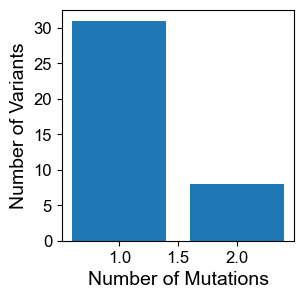

In [33]:
print("Number of sequenced lineages:" + str(len(df_flask.True_Barcode.drop_duplicates())))
print("Number of mutated lineages:" + str(len(df_mutatedbarcodes.True_Barcode.drop_duplicates())))
print("Number of mutations:" + str(len(df_mutatedbarcodes)))

"""
The following code is to calculate the number of mutations per variant
"""
plt.figure(figsize = [3,3])
plt.bar([1,2],pd.DataFrame(df_mutatedbarcodes[['Sample','True_Barcode']].value_counts()).rename(columns = {'count':'Count'}).Count.value_counts())
plt.xticks(rotation = 0, fontname = 'Arial', fontsize = 12);
plt.yticks(rotation = 0, fontname = 'Arial', fontsize = 12);
plt.xlabel('Number of Mutations', fontname = 'Arial', fontsize = 14)
plt.ylabel('Number of Variants', fontname = 'Arial', fontsize = 14)
plt.savefig('Figures paper/mutationspervariant.svg', format = 'svg', dpi = 300)

In [34]:
#Numrber of variants with single versus multiple mutations
pd.DataFrame(df_mutatedbarcodes[['Sample','True_Barcode']].value_counts()).rename(columns = {'count':'Count'}).Count.value_counts()

Count
1    31
2     8
Name: count, dtype: int64

In [35]:
#Calculate the number of variants sampled from different fractions
df_plank = df_flask.loc[df_flask.Sample.str[0] == 'C']
df_disc1 = df_flask.loc[df_flask.Sample.str[0] == 'D']
df_disc2 = df_flask.loc[df_flask.Sample.str[0] == 'E']
print("Variants from planktonic:" + str(len(df_plank.True_Barcode.drop_duplicates().value_counts())))
print("Variants from disc A:" + str(len(df_disc1.True_Barcode.drop_duplicates().value_counts())))
print("Variants from disc B:" + str(len(df_disc2.True_Barcode.drop_duplicates().value_counts())))

Variants from planktonic:19
Variants from disc A:38
Variants from disc B:48


In [36]:
df_subset = df_biofilm_filtered.loc[
    df_biofilm_filtered.index.isin(df_flask.True_Barcode)
].copy()

#Find the frequency of the different variants at the end of the experiment
for barcode in df_subset.index:
    df_flask.loc[df_flask.True_Barcode == barcode, 'Plank_final'] = df_subset.loc[barcode, 't_169_f']
    df_flask.loc[df_flask.True_Barcode == barcode, 'Disc1_final'] = df_subset.loc[barcode, 't_176_f']
    df_flask.loc[df_flask.True_Barcode == barcode, 'Disc2_final'] = df_subset.loc[barcode, 't_177_f']
    df_flask.loc[df_flask.True_Barcode == barcode, 'Disc3_final'] = df_subset.loc[barcode, 't_175_f']
    df = df_flask.loc[df_flask.True_Barcode == barcode]
    df = df.replace(np.nan, '')
    gene_string = ''
    for i in range(len(df)):
        gene_string = gene_string + df.iloc[i].gene + ' ' + df.iloc[i].annotation + ', '
    df_subset.loc[barcode, 'Mutation'] = gene_string[0:-2]
df_subset

C:\Users\achoudhu\AppData\Local\Temp\ipykernel_15300\2720183225.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(np.nan, '')
C:\Users\achoudhu\AppData\Local\Temp\ipykernel_15300\2720183225.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(np.nan, '')


,3,8,28,32,42,64,70,78,100,108,...,slope_I,slope_J,slope_K,slope_L,slope_M,fitness_normed_N,slope_N,Fitness_pDMS,Is_fit,Mutation
barcode,,,,,,,,,,,,,,,,,,,,,
CGTATGCCCTGTTGAAGGCC,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,yciB ← T33R (ACG→AGG)
GCCCGTGCCAGGGTTCCTAA,1.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,"rlmB → / → yjfI intergenic (+47/‑80), ipbA ← /..."
TGGGTGTTTTGACGAGTGGT,1.0,2.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,No Mutation
GATATCTTCGGCTGATTGAG,1.0,5.0,0.0,6.0,3.0,3.0,0.0,2.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,No Mutation
AGTTGCGTCCCTTTTATGGA,1.0,4.0,1.0,3.0,12.0,5.0,5.0,10.0,4.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,LF82_RS13695 → A238V (GCC→GTC)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTTTCATCCATAGCTACCGA,2.0,0.0,8.0,8.0,6.0,7.0,5.0,8.0,1.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,No Mutation
ATCATTGGACTTTAATTGAA,2.0,1.0,1.0,4.0,5.0,1.0,7.0,12.0,4.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,No Mutation
ATTTTAGGCTGTTACCACAA,3.0,0.0,0.0,1.0,3.0,0.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,No Mutation


In [37]:
df_flask[['gene', 'Plank_final' ,'Disc1_final', 'Disc2_final', 'Disc3_final']]\
.groupby('gene').sum().sort_values('Plank_final', ascending = 0)

,Plank_final,Disc1_final,Disc2_final,Disc3_final
gene,,,,
fimH →,0.382048,0.169128,0.117548,0.161912
crp →,0.048860,0.009776,0.012520,0.018568
bcsG →,0.023352,0.002060,0.002856,0.006480
No Mutation,0.016980,0.010100,0.010772,0.018476
ydiV ←,0.016464,0.008264,0.009308,0.017584
arnB →,0.012524,0.010608,0.003436,0.004488
cyaA →,0.011376,0.005192,0.008680,0.011408
atoS →,0.005520,0.002264,0.002420,0.006836
prfA →,0.003360,0.005908,0.017020,0.026332


In [38]:
#We isolate all the barcodes that have been sequenced in table called df_subset
df_subset = df_biofilm_filtered.loc[
    df_biofilm_filtered.index.isin(df_flask.True_Barcode)
].copy()

#All the barcodes that are mutated as assigned a tag 'Yes' for columns mutated
df_subset.loc[:,'Mutated'] = 'No'
df_subset.loc[df_subset.index.isin(df_mutatedbarcodes.True_Barcode),'Mutated'] = 'Yes'

df_subset.Mutated.value_counts()

Mutated
No     66
Yes    38
Name: count, dtype: int64

In [39]:
import numpy as np
import pandas as pd
from itertools import combinations, product

# --- ENRICHMENT THRESHOLD ---
cols = [f"t_{i}_enrichment" for i in range(8, 12)]
enrichment_values = [
    df_biofilm_filtered[col].mean() + 1.96 * df_biofilm_filtered[col].std()
    for col in cols
]
enrichment_threshold = np.mean(enrichment_values) + 1.96 * np.std(enrichment_values)

enrichment_threshold

np.float64(0.635982110535727)

In [40]:
print("both")
print(df_subset.loc[(df_subset.t_176_enrichment >= enrichment_threshold) & (df_subset.t_177_enrichment >= enrichment_threshold)]\
[['t_176_enrichment','t_177_enrichment','Mutated']].Mutated.value_counts())

print("One disc")
print(df_subset.loc[(df_subset.t_176_enrichment >= enrichment_threshold) & (df_subset.t_177_enrichment < enrichment_threshold)]\
[['t_176_enrichment','t_177_enrichment','Mutated']].Mutated.value_counts())

print("One disc")
print(df_subset.loc[(df_subset.t_176_enrichment < enrichment_threshold) & (df_subset.t_177_enrichment >= enrichment_threshold)]\
[['t_176_enrichment','t_177_enrichment','Mutated']].Mutated.value_counts())

print("neither")
print(df_subset.loc[(df_subset.t_176_enrichment < enrichment_threshold) & (df_subset.t_177_enrichment < enrichment_threshold)]\
[['t_176_enrichment','t_177_enrichment','Mutated']].Mutated.value_counts())

both
Mutated
Yes    20
Name: count, dtype: int64
One disc
Mutated
No     14
Yes     2
Name: count, dtype: int64
One disc
Mutated
No     10
Yes     2
Name: count, dtype: int64
neither
Mutated
No     42
Yes    14
Name: count, dtype: int64


In [41]:
#Define a new parameter to =see if variants are shared between discs
df_biofilm_filtered.loc[(df_biofilm_filtered.t_176_enrichment >= enrichment_threshold) & (df_biofilm_filtered.t_177_enrichment >= enrichment_threshold), 'Enrich'] = 'Both'

df_biofilm_filtered.loc[(df_biofilm_filtered.t_176_enrichment >= enrichment_threshold) & (df_biofilm_filtered.t_177_enrichment < enrichment_threshold), 'Enrich'] = 'One disc only'

df_biofilm_filtered.loc[(df_biofilm_filtered.t_176_enrichment < enrichment_threshold) & (df_biofilm_filtered.t_177_enrichment >= enrichment_threshold), 'Enrich'] = 'One disc only'

df_biofilm_filtered.loc[(df_biofilm_filtered.t_176_enrichment < enrichment_threshold) & (df_biofilm_filtered.t_177_enrichment < enrichment_threshold), 'Enrich'] = 'None'

df_subset.loc[(df_subset.t_176_enrichment >= enrichment_threshold) & (df_subset.t_177_enrichment >= enrichment_threshold), 'Enrich'] = 'Both'

df_subset.loc[(df_subset.t_176_enrichment >= enrichment_threshold) & (df_subset.t_177_enrichment < enrichment_threshold), 'Enrich'] = 'One disc only'

df_subset.loc[(df_subset.t_176_enrichment < enrichment_threshold) & (df_subset.t_177_enrichment >= enrichment_threshold), 'Enrich'] = 'One disc only'

df_subset.loc[(df_subset.t_176_enrichment < enrichment_threshold) & (df_subset.t_177_enrichment < enrichment_threshold), 'Enrich'] = 'None'


In [42]:
import numpy as np
import pandas as pd
from itertools import combinations, product

# --- ENRICHMENT THRESHOLD ---
cols = [f"t_{i}_enrichment" for i in range(8, 12)]
enrichment_values = [
    df_biofilm_filtered[col].mean() + 1.96 * df_biofilm_filtered[col].std()
    for col in cols
]
enrichment_threshold = np.mean(enrichment_values) + 1.96 * np.std(enrichment_values)

# --- DISC GROUPS ---
disc_groups = {
    'A': ['12', '13', '14'],
    'B': ['15', '16', '17'],
}

records = []

# --- TWO DISCS (SAME WELL) ---
for replicate, discs in disc_groups.items():
    for d1, d2 in combinations(discs, 2):
        mask = (
            (df_biofilm_filtered[f't_{d1}_enrichment'] >= enrichment_threshold) &
            (df_biofilm_filtered[f't_{d2}_enrichment'] >= enrichment_threshold)
        )
        df1 = df_biofilm_filtered.loc[mask]
        for disc in (d1, d2):
            records.append({
                'Sample': 'Initial',
                'Replicate': replicate,
                'Fraction': df1[f't_{disc}_f'].sum()
            })

disc_groups = {
    'A': ['172', '173', '174'],
    'B': ['175', '176', '177'],
}

# --- TWO DISCS (SAME WELL) ---
for replicate, discs in disc_groups.items():
    for d1, d2 in combinations(discs, 2):
        mask = (
            (df_biofilm_filtered[f't_{d1}_enrichment'] >= enrichment_threshold) &
            (df_biofilm_filtered[f't_{d2}_enrichment'] >= enrichment_threshold)
        )
        df1 = df_biofilm_filtered.loc[mask]
        for disc in (d1, d2):
            records.append({
                'Sample': 'Final',
                'Replicate': replicate,
                'Fraction': df1[f't_{disc}_f'].sum()
            })

# --- FINAL DATAFRAME ---
df_samples = pd.DataFrame(records)
df_samples

,Sample,Replicate,Fraction
0,Initial,A,0.034696
1,Initial,A,0.023168
2,Initial,A,0.054584
3,Initial,A,0.017656
4,Initial,A,0.047936
5,Initial,A,0.033080
6,Initial,B,0.034816
7,Initial,B,0.029372
8,Initial,B,0.042820
9,Initial,B,0.027308


In [43]:
df_samples[['Sample','Fraction']].groupby('Sample').mean()

,Fraction
Sample,
Final,0.302969
Initial,0.034785


In [44]:
df_samples[['Sample','Fraction']].groupby('Sample').std()

,Fraction
Sample,
Final,0.046381
Initial,0.010451


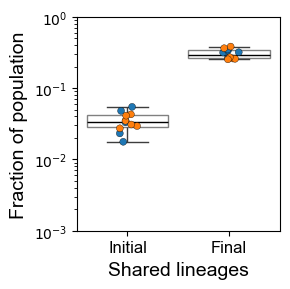

In [45]:
df_probability_enrichment = df_samples
plt.figure(figsize = [3,3])
sns.stripplot(data=df_probability_enrichment, x="Sample", y="Fraction", hue = 'Replicate', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='Sample', y='Fraction', data=df_probability_enrichment,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))

plt.xticks(ha = 'center', fontname = 'arial', fontsize = 12)
plt.xticks(fontname = 'arial', fontsize = 12)

plt.yscale('log')
plt.ylim([0.001,1])
plt.xlabel('Shared lineages', fontname = 'Arial', fontsize = 14)
plt.ylabel('Fraction of population', fontname = 'Arial', fontsize = 14)
plt.tight_layout()
plt.savefig('Figures paper/Change in fraction of shared lineages.svg', format = 'svg', dpi = 300)

In [46]:
print("Fraction of population on disc A with Fitness > 0")
print(df_biofilm_filtered.loc[(df_biofilm_filtered.Fitness > 0)].t_176_f.sum())

print("Fraction of population on disc A with Fitness > 0 and shared between multiple discs")
print(df_biofilm_filtered.loc[(df_biofilm_filtered.Enrich == 'Both') & (df_biofilm_filtered.Fitness > 0)].t_176_f.sum())

print("Fraction of population on disc B with Fitness > 0")
print(df_biofilm_filtered.loc[(df_biofilm_filtered.Fitness > 0)].t_177_f.sum())

print("Fraction of population on disc B with Fitness > 0 and shared between multiple discs")
print(df_biofilm_filtered.loc[(df_biofilm_filtered.Enrich == 'Both') & (df_biofilm_filtered.Fitness > 0)].t_177_f.sum())

print("Fraction of population on disc B with Fitness > 0")
print(df_biofilm_filtered.loc[(df_biofilm_filtered.Fitness > 0)].t_175_f.sum())

print("Fraction of population on disc B with Fitness > 0 and shared between multiple discs")
print(df_biofilm_filtered.loc[(df_biofilm_filtered.Enrich == 'Both') & (df_biofilm_filtered.Fitness > 0)].t_175_f.sum())

Fraction of population on disc A with Fitness > 0
0.27627999999999997
Fraction of population on disc A with Fitness > 0 and shared between multiple discs
0.23382399999999998
Fraction of population on disc B with Fitness > 0
0.27123200000000003
Fraction of population on disc B with Fitness > 0 and shared between multiple discs
0.22554400000000002
Fraction of population on disc B with Fitness > 0
0.44260800000000006
Fraction of population on disc B with Fitness > 0 and shared between multiple discs
0.34125200000000006


In [47]:
print("Mean shared population with fitness > 0 =" + str(np.mean([84.64,83.14,77.09,84.7,88.2,89.7])))
print("Std shared population with fitness > 0 =" + str(np.std([84.64,83.14,77.09,84.7,88.2,89.7])))

Mean shared population with fitness > 0 =84.57833333333333
Std shared population with fitness > 0 =4.031345584568783


In [48]:
print(df_biofilm_filtered.loc[df_biofilm_filtered.Enrich == 'One disc only'].t_176_f.sum())
print(df_biofilm_filtered.loc[(df_biofilm_filtered.Enrich == 'One disc only') & (df_biofilm_filtered.Fitness > 0)].t_176_f.sum())
print(df_biofilm_filtered.loc[(df_biofilm_filtered.Fitness > 0)].t_176_f.sum())


0.38078
0.002408
0.27627999999999997


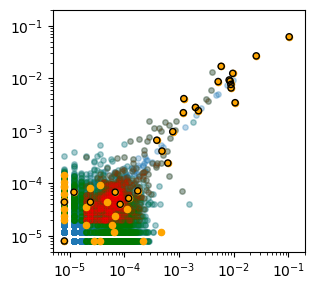

In [49]:
list_files = ['3','8','28','32','42','64','70','78','100','108','116','134','140','144','160','164','168',\
            '12','48','84','120','148','172','13','49','85','121','149','173','14','50','86','122','150','174',\
            '9','29','33','46','65','74','82','101','109','117','138','142','146','161','165','169',\
            '15','51','87','123','151','175','16','52','88','124','152','176','17','53','89','125','153','177',\
             '10','30','34','43','66','71','79','102','110','118','139','141','145','162','166','170',\
              '18','54','90','126','154','178','19','55','91','127','155','179','20','56','92','128','156','180',\
            '11','31','35','47','67','75','83','103','111','119','135','143','147','163','167','171',\
              '21','57','93','129','157','181','22','58','94','130','158','182','23','59','95','131','159','183',\
            '4','24','36','40','60','68','76','96','104','112','132','5','25','37','44','61','72','80','97','105','113','136',\
            '6','26','38','41','62','69','77','98','106','114','133','7','27','39','45','63','73','81','99','107','115','137']

for i in list_files:
    df_biofilm_filtered.loc[:,'t_'+i+'_f2'] = (df_biofilm_filtered[i]+1)/df_biofilm_filtered[i].sum()

A1 = ['176']
A2 = ['177']
i = 0

df_plot = df_biofilm_filtered
plt.figure(figsize=[3.25,3])
plt.scatter(df_plot['t_'+A1[i]+'_f2'],df_plot['t_'+A2[i]+'_f2'], s = 15, alpha = 0.3, rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in discA
df1 = df_plot.loc[(df_plot['t_'+A1[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df1['t_'+A1[i]+'_f2'], df1['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'green', rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in discB
df2 = df_plot.loc[(df_plot['t_'+A2[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df2['t_'+A1[i]+'_f2'], df2['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'green', rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in disc A amd disc B
df3 = df_plot.loc[(df_plot['t_'+A1[i]+'_enrichment'] >= enrichment_threshold) & (df_plot['t_'+A2[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df3['t_'+A1[i]+'_f2'], df3['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'red', rasterized = True)



#We isolate all the barcodes that have been sequenced in table called df_subset
df_subset = df_biofilm_filtered.loc[
    df_biofilm_filtered.index.isin(df_flask.True_Barcode)
].copy()

#All the barcodes that are mutated as assigned a tag 'Yes' for columns mutated
df_subset.loc[:,'Mutated'] = 'No'
df_subset.loc[df_subset.index.isin(df_mutatedbarcodes.True_Barcode),'Mutated'] = 'Yes'

df_plot = df_subset
plt.scatter(df_plot.t_176_f2, df_plot.t_177_f2, alpha = 1, s = 20, rasterized = True, facecolors='orange')

df_plot = df_subset.loc[(df_subset.Mutated == 'Yes')]
plt.scatter(df_plot.t_176_f2, df_plot.t_177_f2, alpha = 1, s = 20, edgecolor = 'black', rasterized = True, facecolors='none')

plt.xlim(5*10**(-6), 0.2)
plt.ylim(5*10**(-6), 0.2)
    
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.savefig('Figures paper/Sampled Mutations.svg', format = 'svg', dpi = 300)

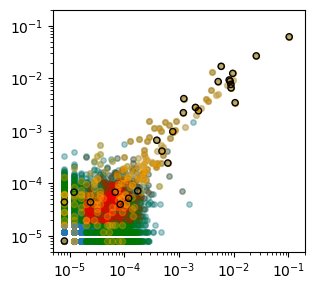

In [50]:
A1 = ['176']
A2 = ['177']
i = 0

df_plot = df_biofilm_filtered
plt.figure(figsize=[3.25,3])
plt.scatter(df_plot['t_'+A1[i]+'_f2'],df_plot['t_'+A2[i]+'_f2'], s = 15, alpha = 0.3, rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in discA
df1 = df_plot.loc[(df_plot['t_'+A1[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df1['t_'+A1[i]+'_f2'], df1['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'green', rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in discB
df2 = df_plot.loc[(df_plot['t_'+A2[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df2['t_'+A1[i]+'_f2'], df2['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'green', rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in disc A amd disc B
df3 = df_plot.loc[(df_plot['t_'+A1[i]+'_enrichment'] >= enrichment_threshold) & (df_plot['t_'+A2[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df3['t_'+A1[i]+'_f2'], df3['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'red', rasterized = True)

df_plot = df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0]
plt.scatter(df_plot.t_176_f2, df_plot.t_177_f2, alpha = 0.3, s = 20, rasterized = True, facecolors='orange')

df_plot = df_subset.loc[(df_subset.Mutated == 'Yes')]
plt.scatter(df_plot.t_176_f2, df_plot.t_177_f2, alpha = 1, s = 20, edgecolor = 'black', rasterized = True, facecolors='none')

plt.xlim(5*10**(-6), 0.2)
plt.ylim(5*10**(-6), 0.2)
    
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.savefig('Figures paper/Sampled Mutations A1.svg', format = 'svg', dpi = 300)

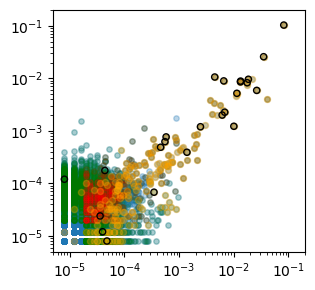

In [51]:
A1 = ['175']
A2 = ['176']
i = 0

df_plot = df_biofilm_filtered
plt.figure(figsize=[3.25,3])
plt.scatter(df_plot['t_'+A1[i]+'_f2'],df_plot['t_'+A2[i]+'_f2'], s = 15, alpha = 0.3, rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in discA
df1 = df_plot.loc[(df_plot['t_'+A1[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df1['t_'+A1[i]+'_f2'], df1['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'green', rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in discB
df2 = df_plot.loc[(df_plot['t_'+A2[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df2['t_'+A1[i]+'_f2'], df2['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'green', rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in disc A amd disc B
df3 = df_plot.loc[(df_plot['t_'+A1[i]+'_enrichment'] >= enrichment_threshold) & (df_plot['t_'+A2[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df3['t_'+A1[i]+'_f2'], df3['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'red', rasterized = True)

df_plot = df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0]
plt.scatter(df_plot.t_175_f2, df_plot.t_176_f2, alpha = 0.3, s = 20, rasterized = True, facecolors='orange')

df_plot = df_subset.loc[(df_subset.Mutated == 'Yes')]
plt.scatter(df_plot.t_175_f2, df_plot.t_176_f2, alpha = 1, s = 20, edgecolor = 'black', rasterized = True, facecolors='none')

plt.xlim(5*10**(-6), 0.2)
plt.ylim(5*10**(-6), 0.2)
    
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.savefig('Figures paper/Sampled Mutations A2.svg', format = 'svg', dpi = 300)

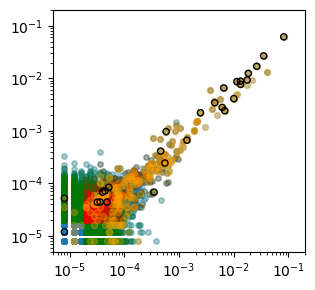

In [52]:
A1 = ['175']
A2 = ['177']
i = 0

df_plot = df_biofilm_filtered
plt.figure(figsize=[3.25,3])
plt.scatter(df_plot['t_'+A1[i]+'_f2'],df_plot['t_'+A2[i]+'_f2'], s = 15, alpha = 0.3, rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in discA
df1 = df_plot.loc[(df_plot['t_'+A1[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df1['t_'+A1[i]+'_f2'], df1['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'green', rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in discB
df2 = df_plot.loc[(df_plot['t_'+A2[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df2['t_'+A1[i]+'_f2'], df2['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'green', rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in disc A amd disc B
df3 = df_plot.loc[(df_plot['t_'+A1[i]+'_enrichment'] >= enrichment_threshold) & (df_plot['t_'+A2[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df3['t_'+A1[i]+'_f2'], df3['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'red', rasterized = True)

df_plot = df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0]
plt.scatter(df_plot.t_175_f2, df_plot.t_177_f2, alpha = 0.3, s = 20, rasterized = True, facecolors='orange')

df_plot = df_subset.loc[(df_subset.Mutated == 'Yes')]
plt.scatter(df_plot.t_175_f2, df_plot.t_177_f2, alpha = 1, s = 20, edgecolor = 'black', rasterized = True, facecolors='none')

plt.xlim(5*10**(-6), 0.2)
plt.ylim(5*10**(-6), 0.2)
    
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.savefig('Figures paper/Sampled Mutations A3.svg', format = 'svg', dpi = 300)

In [53]:
import numpy as np
import pandas as pd
from itertools import combinations, product

# --- ENRICHMENT THRESHOLD ---
cols = [f"t_{i}_enrichment" for i in range(8, 12)]
enrichment_values = [
    df_biofilm_filtered[col].mean() + 1.96 * df_biofilm_filtered[col].std()
    for col in cols
]
enrichment_threshold = np.mean(enrichment_values) + 1.96 * np.std(enrichment_values)

enrichment_threshold
# ------------------------------------------------------------
# TIMEPOINT DEFINITIONS FOR EACH DISC in replicate B
# Each group contains six timepoints for that disc
# ------------------------------------------------------------
B1 = ['15','51','87','123','151','175']
B2 = ['16','52','88','124','152','176']
B3 = ['17','53','89','125','153','177']

records = []

for i in range(len(B1)):
    mask = (
        (df_biofilm_filtered['t_'+B1[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+B2[i]+'_enrichment'] < enrichment_threshold) &
        (df_biofilm_filtered['t_'+B3[i]+'_enrichment'] < enrichment_threshold)
    )
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B1[i]+'_f'].sum()
    records.append({
            'Sample': 'One disc',
            'Time': i,
            'Fraction': fraction_sum
        })
for i in range(len(B2)):
    mask = (
        (df_biofilm_filtered['t_'+B2[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+B1[i]+'_enrichment'] < enrichment_threshold) &
        (df_biofilm_filtered['t_'+B3[i]+'_enrichment'] < enrichment_threshold)
    )
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B2[i]+'_f'].sum()
    records.append({
            'Sample': 'One disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    
for i in range(len(B3)):
    mask = (
        (df_biofilm_filtered['t_'+B3[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+B1[i]+'_enrichment'] < enrichment_threshold) &
        (df_biofilm_filtered['t_'+B2[i]+'_enrichment'] < enrichment_threshold)
    )
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B3[i]+'_f'].sum()
    records.append({
            'Sample': 'One disc',
            'Time': i,
            'Fraction': fraction_sum
        })

for i in range(len(B1)):
    mask = (
        (df_biofilm_filtered['t_'+B1[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+B2[i]+'_enrichment'] >= enrichment_threshold))
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B1[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B2[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })

for i in range(len(B1)):
    mask = (
        (df_biofilm_filtered['t_'+B1[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+B3[i]+'_enrichment'] >= enrichment_threshold))
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B1[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B3[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    
for i in range(len(B1)):
    mask = (
        (df_biofilm_filtered['t_'+B2[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+B3[i]+'_enrichment'] >= enrichment_threshold))
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B3[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B2[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })

df_probability_enrichment_B = pd.DataFrame(records)
df_probability_enrichment_B.loc[2,'Fraction'] = np.nan
df_probability_enrichment_B.loc[22,'Fraction'] = np.nan
df_probability_enrichment_B

,Sample,Time,Fraction
0,One disc,0,0.730380
1,One disc,1,0.545608
2,One disc,2,NaN
3,One disc,3,0.230548
4,One disc,4,0.394372
5,One disc,5,0.085544
6,One disc,0,0.719724
7,One disc,1,0.248924
8,One disc,2,0.250256
9,One disc,3,0.279052


In [54]:
#Mean lineages enriched on a single disc over time
df_probability_enrichment_B.loc[df_probability_enrichment_B.Sample == 'One disc']\
.dropna()[['Time', 'Fraction']].groupby('Time').mean()

,Fraction
Time,
0,0.714880
1,0.363687
2,0.281286
3,0.226744
4,0.240109
5,0.213736


In [55]:
#Std lineages enriched on a single disc over time
df_probability_enrichment_B.loc[df_probability_enrichment_B.Sample == 'One disc']\
.dropna()[['Time', 'Fraction']].groupby('Time').std()

,Fraction
Time,
0,0.018406
1,0.159336
2,0.043883
3,0.054310
4,0.151124
5,0.132763


In [56]:
df_probability_enrichment_B.to_excel('Figurewise raw data/Supplementary figure 10B.xlsx')

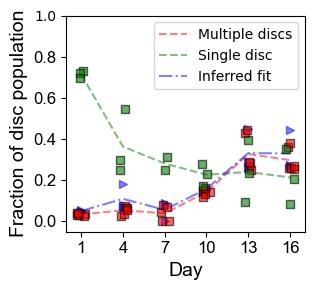

In [57]:
plt.figure(figsize = [3.25,3])

B1 = ['15','51','87','123','151','175']
B2 = ['16','52','88','124','152','176']
B3 = ['17','53','89','125','153','177']

# Red-edged white boxplots for Disc B data
sns.stripplot(x='Time', y='Fraction', data=df_probability_enrichment_B.loc[df_probability_enrichment_B.Sample == 'Two disc'], color='red', alpha=0.6,
              s=6, edgecolor='black', marker="s", linewidth=1, label = '' )

plt.plot([0,1,2,3,4,5], df_probability_enrichment_B.loc[df_probability_enrichment_B['Sample'] == 'Two disc']\
[['Time', 'Fraction']].groupby('Time').mean(), '--', color = 'red', label = 'Multiple discs', alpha = 0.5)

# Red-edged white boxplots for Disc B data
sns.stripplot(x='Time', y='Fraction', data=df_probability_enrichment_B.loc[df_probability_enrichment_B.Sample == 'One disc'], color='green', alpha=0.6,
              s=6, edgecolor='black', marker="s", linewidth=1, label = '' )

plt.plot([0,1,2,3,4,5], df_probability_enrichment_B.loc[df_probability_enrichment_B['Sample'] == 'One disc']\
[['Time', 'Fraction']].groupby('Time').mean(), '--', color = 'green', label = 'Single disc', alpha = 0.5)


df1 = pd.DataFrame(df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0]\
[['t_15_f', 't_51_f', 't_87_f', 't_123_f', 't_151_f', 't_175_f']].sum()).reset_index(drop = True).rename(columns = {0:'A1'})

df2 = pd.DataFrame(df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0]\
[['t_16_f', 't_52_f', 't_88_f', 't_124_f', 't_152_f', 't_176_f']].sum()).reset_index(drop = True).rename(columns = {0:'A2'})

df3 = pd.DataFrame(df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0]\
[['t_17_f', 't_53_f', 't_89_f', 't_125_f', 't_153_f', 't_177_f']].sum()).reset_index(drop = True).rename(columns = {0:'A3'})

df_resistance = pd.concat([df1,df2,df3], axis = 1)

plt.plot([0,1,2,3,4,5], df_resistance, '>', color = 'blue', alpha = 0.5)
plt.plot([0,1,2,3,4,5], df_resistance.mean(axis = 1), '-.', color = 'blue', alpha = 0.5, label = 'Inferred fit',)

plt.legend()

plt.xlabel('Day', fontname = 'Arial', fontsize = 14)
plt.ylabel('Fraction of disc population', fontname = 'Arial', fontsize = 14)
plt.legend(ncol = 1, fontsize = 10)

plt.xticks([0,1,2,3,4,5], [1,4,7,10,13,16], fontname='Arial', fontsize=12)
plt.yticks(fontname = 'Arial', fontsize = 12)

plt.ylim([-0.05,1])

plt.tight_layout()

plt.savefig('Figures paper/Binding probability temporal.svg', format = 'svg', dpi = 300)

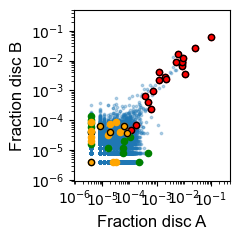

In [32]:


df_biofilm_filtered.loc[(df_biofilm_filtered.t_176_enrichment >= enrichment_threshold) & (df_biofilm_filtered.t_177_enrichment >= enrichment_threshold), 'Enrich'] = 'Both'

df_biofilm_filtered.loc[(df_biofilm_filtered.t_176_enrichment >= enrichment_threshold) & (df_biofilm_filtered.t_177_enrichment < enrichment_threshold), 'Enrich'] = 'One disc only'

df_biofilm_filtered.loc[(df_biofilm_filtered.t_176_enrichment < enrichment_threshold) & (df_biofilm_filtered.t_177_enrichment >= enrichment_threshold), 'Enrich'] = 'One disc only'

df_biofilm_filtered.loc[(df_biofilm_filtered.t_176_enrichment < enrichment_threshold) & (df_biofilm_filtered.t_177_enrichment < enrichment_threshold), 'Enrich'] = 'None'

df_subset.loc[(df_subset.t_176_enrichment >= enrichment_threshold) & (df_subset.t_177_enrichment >= enrichment_threshold), 'Enrich'] = 'Both'

df_subset.loc[(df_subset.t_176_enrichment >= enrichment_threshold) & (df_subset.t_177_enrichment < enrichment_threshold), 'Enrich'] = 'One disc only'

df_subset.loc[(df_subset.t_176_enrichment < enrichment_threshold) & (df_subset.t_177_enrichment >= enrichment_threshold), 'Enrich'] = 'One disc only'

df_subset.loc[(df_subset.t_176_enrichment < enrichment_threshold) & (df_subset.t_177_enrichment < enrichment_threshold), 'Enrich'] = 'None'

import matplotlib.ticker as ticker

plt.figure(figsize=[2.5,2.5])
df = df_biofilm_filtered.loc[(df_biofilm_filtered['176'] >= 1)|\
                                 (df_biofilm_filtered['177'] >= 1)]
plt.scatter(df.t_176_f, df.t_177_f, alpha = 0.3, s = 3, rasterized = True)


df_plot = df_subset.loc[df_subset.Enrich == 'Both']
plt.scatter(df_plot.t_176_f, df_plot.t_177_f, alpha = 1, s = 20, rasterized = True, color = 'red')

df_plot = df_subset.loc[(df_subset.Enrich == 'Both') & (df_subset.Mutated == 'Yes')]
plt.scatter(df_plot.t_176_f, df_plot.t_177_f, alpha = 1, s = 20, edgecolor = 'black', rasterized = True, color = 'red')

df_plot = df_subset.loc[df_subset.Enrich == 'One disc only']
plt.scatter(df_plot.t_176_f, df_plot.t_177_f, alpha = 1, s = 20, rasterized = True, color = 'green')

df_plot = df_subset.loc[(df_subset.Enrich == 'One disc only') & (df_subset.Mutated == 'Yes')]
plt.scatter(df_plot.t_176_f, df_plot.t_177_f, alpha = 1, s = 20, edgecolor = 'black',rasterized = True, color = 'green')

df_plot = df_subset.loc[df_subset.Enrich == 'None']
plt.scatter(df_plot.t_176_f, df_plot.t_177_f, alpha = 1, s = 20, rasterized = True, color = 'orange')

df_plot = df_subset.loc[(df_subset.Enrich == 'None') & (df_subset.Mutated == 'Yes')]
plt.scatter(df_plot.t_176_f, df_plot.t_177_f, alpha = 1, s = 20, edgecolor = 'black',rasterized = True, color = 'orange')

plt.xscale('log')
plt.yscale('log')


# Add minor ticks to both axes
ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(1, 10) * 0.1, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(1, 10) * 0.1, numticks=10))

plt.xlim([9*10**(-7),0.5])
plt.ylim([9*10**(-7),0.5])

plt.xlabel('Fraction disc A', fontname = 'Arial', fontsize = 12)
plt.ylabel('Fraction disc B', fontname = 'Arial', fontsize = 12)

plt.tight_layout()

plt.savefig('Figures paper/Sampled Mutations.svg', format = 'svg', dpi = 300)

In [40]:
print(df_subset.loc[df_subset.Fitness_pDMS > 0].Mutated.value_counts())
print(df_subset.loc[df_subset.Fitness_pDMS == 0].Mutated.value_counts())

import numpy as np
from scipy.stats import fisher_exact

# Contingency table
table = np.array([[19, 0],
                  [19, 66]])

# Fisher's exact test (default: two-sided)
oddsratio, p_value = fisher_exact(table, alternative='two-sided')

print("Odds Ratio:", oddsratio)
print("p-value:", p_value)


Mutated
Yes    19
Name: count, dtype: int64
Mutated
No     66
Yes    19
Name: count, dtype: int64
Odds Ratio: inf
p-value: 1.1760694865760312e-10


In [34]:
import numpy as np
from scipy.stats import fisher_exact

# contingency table
table = np.array([[18, 0],
                  [20, 65]])

# Fisher's exact test
oddsratio, pval = fisher_exact(table, alternative='greater')
print("Odds Ratio:", oddsratio)
print("p-value:", pval)

# With continuity correction
table_corrected = table + 0.5
oddsratio_corr, pval_corr = fisher_exact(table_corrected, alternative='greater')
print("Corrected Odds Ratio:", oddsratio_corr)
print("Corrected p-value:", pval_corr)


Odds Ratio: inf
p-value: 6.115561330195362e-10
Corrected Odds Ratio: inf
Corrected p-value: 6.115561330195362e-10


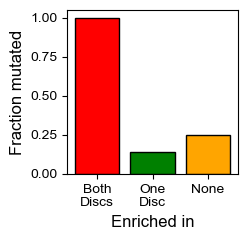

In [153]:
df_mutbysample = pd.read_excel('Figurewise raw data/Supplementary figure 10C Mut_byloc.xlsx', index_col = 0)
df_mutbysample['Both_p'] = df_mutbysample.Both/df_mutbysample.Both.sum()
df_mutbysample['One Disc_p'] = df_mutbysample['One Disc']/df_mutbysample['One Disc'].sum()
df_mutbysample['None_p'] = df_mutbysample['None']/df_mutbysample['None'].sum()

fig,ax = plt.subplots(figsize = [2.5,2.5])
plt.bar(np.arange(3),df_mutbysample[['Both_p','One Disc_p','None_p']].loc['Mutated'], color = ['red','green','orange'], edgecolor = 'black')
plt.xticks(np.arange(3),['Both\nDiscs','One\nDisc', 'None'], rotation = 0, fontname = 'Arial', fontsize = 10)
plt.yticks(fontname = 'Arial', fontsize = 10)
plt.ylabel('Fraction mutated',fontname = 'Arial', fontsize = 12)
plt.xlabel('Enriched in',fontname = 'Arial', fontsize = 12)
plt.tight_layout()
plt.savefig('Figures paper/Mutated by loc.svg', format = 'svg', dpi = 300)


In [154]:
for barcode in df_single.True_Barcode:
    df_single.loc[df_single.True_Barcode == barcode, 'Fitness_DMS'] = df_biofilm_filtered.loc[barcode, 'Fitness_pDMS']

C:\Users\achoudhu\AppData\Local\Temp\ipykernel_31716\528960808.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_single.loc[df_single.True_Barcode == barcode, 'Fitness_DMS'] = df_biofilm_filtered.loc[barcode, 'Fitness_pDMS']


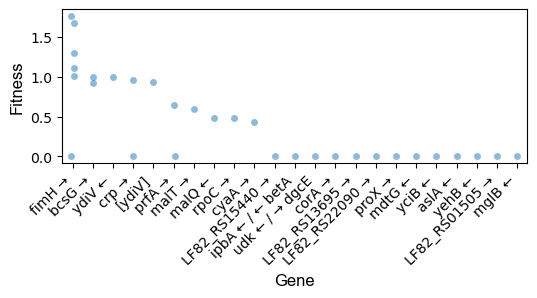

In [39]:
fig,ax = plt.subplots(figsize = [6,2])
sns.stripplot(data = df_single.sort_values('Fitness_DMS', ascending = 0), x = 'gene', y = 'Fitness_DMS', alpha = 0.5, ax = ax)
plt.xticks(rotation = 45, ha = 'right');
plt.xlabel('Gene', fontname = 'Arial', fontsize = 12)
plt.ylabel('Fitness', fontname = 'Arial', fontsize = 12)

plt.savefig('Figures paper/Inferred fitness for single mutations.svg', format = 'svg', dpi = 300)

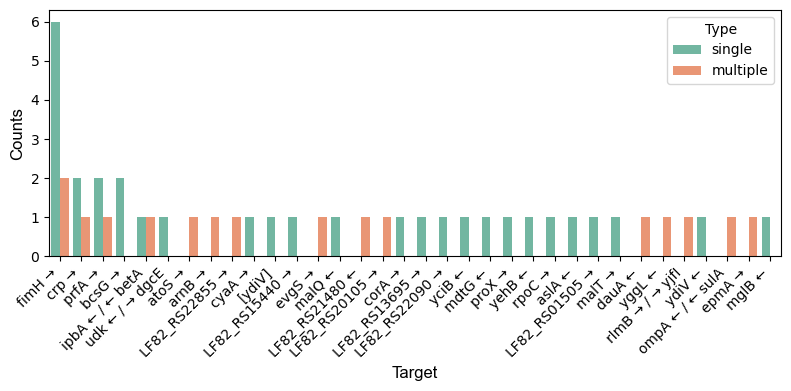

In [155]:
# Count mutations
df_all = df_mutatedbarcodes.gene.value_counts().rename("total")
df_single_mut = df_single.gene.value_counts().rename("single")

# Combine
df = pd.concat([df_all, df_single_mut], axis=1).fillna(0)

# Compute multiple mutations
df["multiple"] = df["total"] - df["single"]

# --- IMPORTANT PART ---
# Make sure the index becomes a real column
df = df.reset_index()

# Detect the index column name (it might NOT be "index")
gene_col = df.columns[0]
df = df.rename(columns={gene_col: "Gene"})
# -----------------------

# Melt
df_long = df.melt(
    id_vars="Gene",
    value_vars=["single", "multiple"],
    var_name="Type",
    value_name="Count"
)

# Plot
plt.figure(figsize=(8,4))
sns.barplot(data=df_long, x="Gene", y="Count", hue="Type", palette="Set2")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.ylabel('Counts',fontname = 'Arial', fontsize = 12)
plt.xlabel('Target',fontname = 'Arial', fontsize = 12)

plt.savefig('Figures paper/Number of mutations by target.svg', format = 'svg', dpi = 300)